In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (14, 5)
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
sales = pd.read_csv('../data/sales_train_validation.csv')

print("Shape:", sales.shape)
# Expected output: (30490, 1919)
# 30490 rows = 30490 unique product-store combinations
# 1919 columns = 6 identifier columns + 1913 days of sales

print("\nColumn names (first 10):")
print(sales.columns[:10].tolist())
# ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', ...]

print("\nColumn names (last 5):")
print(sales.columns[-5:].tolist())
# ['d_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']

print("\nFirst 3 rows:")
sales.head(3)

Shape: (30490, 1919)

Column names (first 10):
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4']

Column names (last 5):
['d_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']

First 3 rows:


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1


In [3]:
id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

for col in id_cols:
    print(f"{col}: {sales[col].nunique()} unique values")
    print(f"  Examples: {sales[col].unique()[:4].tolist()}")
    print()

id: 30490 unique values
  Examples: ['HOBBIES_1_001_CA_1_validation', 'HOBBIES_1_002_CA_1_validation', 'HOBBIES_1_003_CA_1_validation', 'HOBBIES_1_004_CA_1_validation']

item_id: 3049 unique values
  Examples: ['HOBBIES_1_001', 'HOBBIES_1_002', 'HOBBIES_1_003', 'HOBBIES_1_004']

dept_id: 7 unique values
  Examples: ['HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']

cat_id: 3 unique values
  Examples: ['HOBBIES', 'HOUSEHOLD', 'FOODS']

store_id: 10 unique values
  Examples: ['CA_1', 'CA_2', 'CA_3', 'CA_4']

state_id: 3 unique values
  Examples: ['CA', 'TX', 'WI']



In [4]:
calendar = pd.read_csv('../data/calendar.csv')

print("Shape:", calendar.shape)
# Expected: (1969, 14) — 1969 days, 14 columns

print("\nAll columns:", calendar.columns.tolist())

print("\nFirst 5 rows:")
print(calendar.head())

print("\nDate range:")
print("Start:", calendar['date'].min())  # 2011-01-29
print("End:  ", calendar['date'].max())  # 2016-06-19

print("\nEvent types:")
print(calendar['event_type_1'].value_counts())

print("\nSNAP columns (food stamp days):")
print(calendar[['snap_CA','snap_TX','snap_WI']].sum())
# Shows how many SNAP days per state

Shape: (1969, 14)

All columns: ['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']

First 5 rows:
         date  wm_yr_wk    weekday  wday  month  year    d event_name_1  \
0  2011-01-29     11101   Saturday     1      1  2011  d_1          NaN   
1  2011-01-30     11101     Sunday     2      1  2011  d_2          NaN   
2  2011-01-31     11101     Monday     3      1  2011  d_3          NaN   
3  2011-02-01     11101    Tuesday     4      2  2011  d_4          NaN   
4  2011-02-02     11101  Wednesday     5      2  2011  d_5          NaN   

  event_type_1 event_name_2 event_type_2  snap_CA  snap_TX  snap_WI  
0          NaN          NaN          NaN        0        0        0  
1          NaN          NaN          NaN        0        0        0  
2          NaN          NaN          NaN        0        0        0  
3          NaN          NaN          NaN        1        1     

In [5]:
prices = pd.read_csv('../data/sell_prices.csv')

print("Shape:", prices.shape)
# Expected: (6,841,121, 4) — over 6 million rows!

print("\nColumns:", prices.columns.tolist())
# ['store_id', 'item_id', 'wm_yr_wk', 'sell_price']

print("\nFirst 5 rows:")
print(prices.head())

print("\nPrice range:")
print(f"Min price: ${prices['sell_price'].min():.2f}")
print(f"Max price: ${prices['sell_price'].max():.2f}")
print(f"Mean price: ${prices['sell_price'].mean():.2f}")

print("\nNumber of unique items with prices:", prices['item_id'].nunique())

Shape: (6841121, 4)

Columns: ['store_id', 'item_id', 'wm_yr_wk', 'sell_price']

First 5 rows:
  store_id        item_id  wm_yr_wk  sell_price
0     CA_1  HOBBIES_1_001     11325        9.58
1     CA_1  HOBBIES_1_001     11326        9.58
2     CA_1  HOBBIES_1_001     11327        8.26
3     CA_1  HOBBIES_1_001     11328        8.26
4     CA_1  HOBBIES_1_001     11329        8.26

Price range:
Min price: $0.01
Max price: $107.32
Mean price: $4.41

Number of unique items with prices: 3049


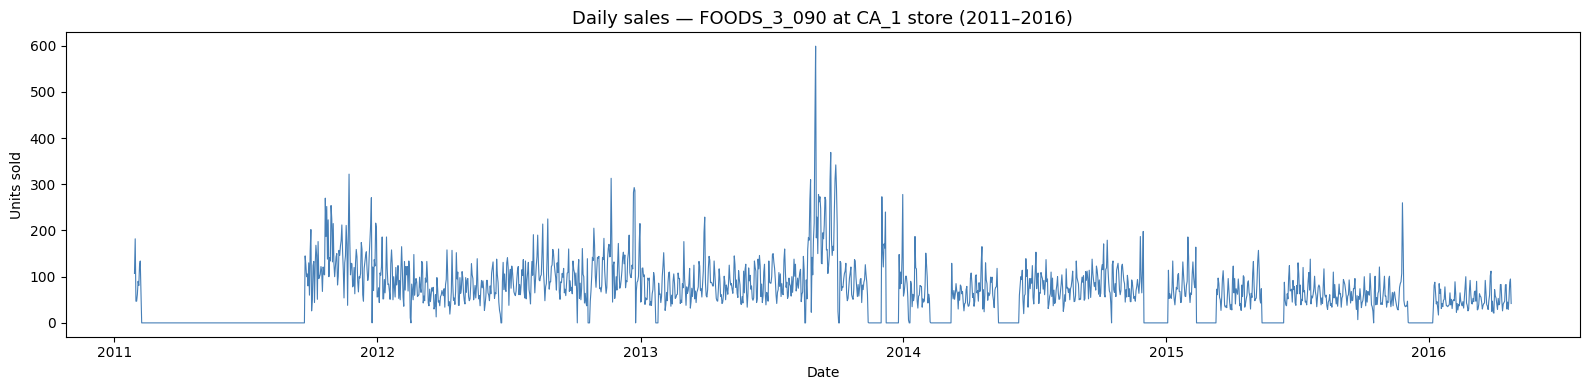

Total units sold: 127,203
Average daily sales: 66.5
Days with zero sales: 469 (24.5%)


In [6]:
# Pick one product and plot its sales history
# This is your first real chart!

# Select one product (FOODS category, store CA_1)
product = sales[sales['id'] == 'FOODS_3_090_CA_1_validation']

# Get just the daily sales columns
day_cols = [c for c in sales.columns if c.startswith('d_')]
product_sales = product[day_cols].values.flatten()

# Merge with calendar to get real dates
calendar['date'] = pd.to_datetime(calendar['date'])
dates = calendar[calendar['d'].isin(day_cols)]['date'].values

# Plot
plt.figure(figsize=(16, 4))
plt.plot(dates, product_sales, linewidth=0.8, color='#185FA5', alpha=0.8)
plt.title('Daily sales — FOODS_3_090 at CA_1 store (2011–2016)', 
          fontsize=13)
plt.xlabel('Date')
plt.ylabel('Units sold')
plt.tight_layout()
plt.savefig('../outputs/01_first_product_sales.png', dpi=150)
plt.show()

print(f"Total units sold: {product_sales.sum():,.0f}")
print(f"Average daily sales: {product_sales.mean():.1f}")
print(f"Days with zero sales: {(product_sales==0).sum()} "
      f"({(product_sales==0).mean()*100:.1f}%)")

In [13]:
print("=" * 50)
print("PHASE 1 VERIFICATION")
print("=" * 50)

# Check 1: Data loaded
assert sales.shape == (30490, 1919), "Sales shape wrong"
print("✓ Sales data: 3,0490 products (Same product in different stores considered separately) × 1,919 days")

# Check 2: Calendar loaded
assert len(calendar) > 1900, "Calendar too short"
print("✓ Calendar: date range",
      calendar['date'].min().date(),
      "to",
      calendar['date'].max().date())

# Check 3: Prices loaded
assert len(prices) > 6_000_000, "Prices file too small"
print(f"✓ Sell prices: {len(prices):,} weekly price records")

# Check 4: Categories correct
assert set(sales['cat_id'].unique()) == {'FOODS','HOBBIES','HOUSEHOLD'}
print("✓ Categories: FOODS, HOBBIES, HOUSEHOLD")

# Check 5: Stores correct
print(f"✓ Stores: {sorted(sales['store_id'].unique())}")

# Check 6: Output folder working
import os
assert os.path.exists('../outputs/01_first_product_sales.png')
print("✓ First chart saved to outputs/")

# Check 7: Libraries
import lightgbm, simpy, mlflow, streamlit
print("✓ All key libraries importable")

print("\n" + "=" * 50)
print("PHASE 1 COMPLETE — ready for EDA")
print("=" * 50)

PHASE 1 VERIFICATION
✓ Sales data: 3,0490 products (Same product in different stores considered separately) × 1,919 days
✓ Calendar: date range 2011-01-29 to 2016-06-19
✓ Sell prices: 6,841,121 weekly price records
✓ Categories: FOODS, HOBBIES, HOUSEHOLD
✓ Stores: ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']
✓ First chart saved to outputs/
✓ All key libraries importable

PHASE 1 COMPLETE — ready for EDA
